In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Dataset path
dataset_path = r"C:\Users\PMLS\Downloads\duplicate\images\imagesmodel\Train"
IMG_SIZE = (128, 128)
categories = ["Fake", "Real"]

data, labels = [], []

# Load and preprocess images
for category in categories:
    folder_path = os.path.join(dataset_path, category)
    label = categories.index(category)
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # Convert grayscale to RGB
        
        data.append(img)
        labels.append(label)

In [3]:
# Convert to NumPy array
data = np.array(data, dtype=np.float32).reshape(-1, 128, 128, 3) / 255.0
labels = np.array(labels, dtype=np.int32)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

from torch.utils.data import DataLoader, TensorDataset

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).squeeze()
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).squeeze()

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
# Initialize EfficientNetV2 model
model = models.efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.DEFAULT")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model.to(device)

# Loss function & optimizer
criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)  # Increased weight decay to reduce overfitting
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.3)  # Adjusted learning rate decay

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)

model.apply(init_weights)  # Initialize weights

# Early stopping parameters
early_stopping_patience = 3
best_test_loss = float('inf')
stopping_counter = 0


In [5]:
# Training loop
train_losses, train_accuracies, test_losses, test_accuracies = [], [], [], []
epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device, dtype=torch.float32), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.4).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluation phase
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device, dtype=torch.float32), labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels.float())
            test_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.3).float()
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    test_loss /= len(test_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    scheduler.step()  # Adjust learning rate
    
    print(f"Epoch {epoch+1} completed. Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.3f}, Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.3f}")
    
    # Early stopping check
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        stopping_counter = 0
    else:
        stopping_counter += 1
        if stopping_counter >= early_stopping_patience:
            print("Early stopping triggered. Training stopped.")
            break


Epoch 1 completed. Train Loss: 0.398, Train Accuracy: 0.795, Test Loss: 0.212, Test Accuracy: 0.882
Epoch 2 completed. Train Loss: 0.163, Train Accuracy: 0.932, Test Loss: 0.130, Test Accuracy: 0.932
Epoch 3 completed. Train Loss: 0.079, Train Accuracy: 0.968, Test Loss: 0.186, Test Accuracy: 0.932
Epoch 4 completed. Train Loss: 0.026, Train Accuracy: 0.991, Test Loss: 0.115, Test Accuracy: 0.960
Epoch 5 completed. Train Loss: 0.014, Train Accuracy: 0.995, Test Loss: 0.142, Test Accuracy: 0.958
Epoch 6 completed. Train Loss: 0.009, Train Accuracy: 0.997, Test Loss: 0.121, Test Accuracy: 0.966
Epoch 7 completed. Train Loss: 0.005, Train Accuracy: 0.999, Test Loss: 0.117, Test Accuracy: 0.966
Early stopping triggered. Training stopped.


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Performance metrics
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

# Save the trained model
torch.save(model.state_dict(), "efficientnet_v2_s_binary.pth")
print("Model saved as efficientnet_v2_s_binary.pth")



Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.96      0.97      2687
         1.0       0.96      0.97      0.97      2513

    accuracy                           0.97      5200
   macro avg       0.97      0.97      0.97      5200
weighted avg       0.97      0.97      0.97      5200

Accuracy: 0.9663461538461539
Precision: 0.9577133907595928
Recall: 0.9733386390768006
F1 Score: 0.9654627985000986
Model saved as efficientnet_v2_s_binary.pth


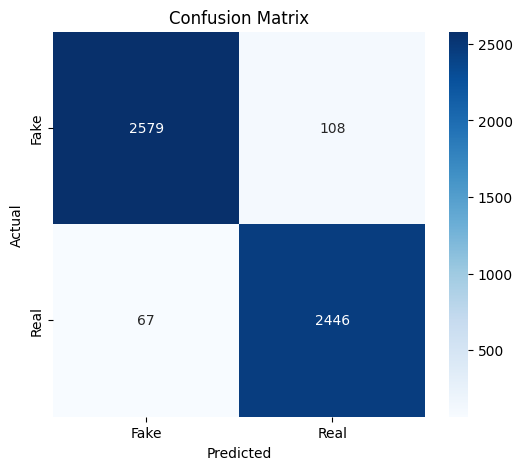

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 1.0, 'Training and Testing Loss')

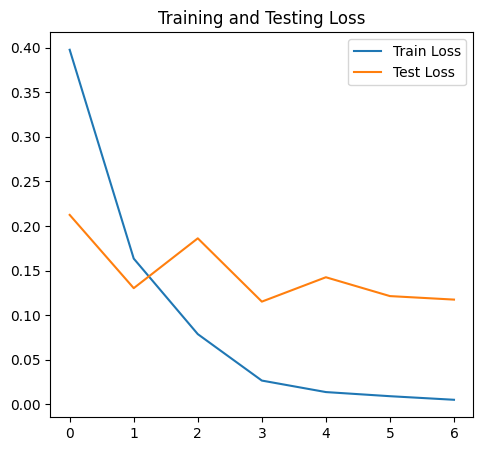

In [13]:
# Plot training and testing loss and accuracy
epochs_range = range(len(train_losses))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.legend()
plt.title("Training and Testing Loss")

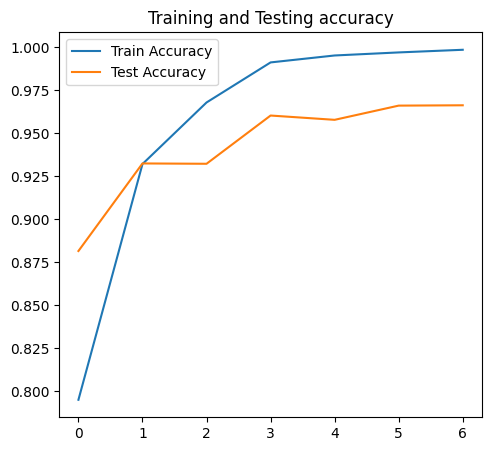

In [14]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.legend()
plt.title("Training and Testing accuracy")
plt.show()

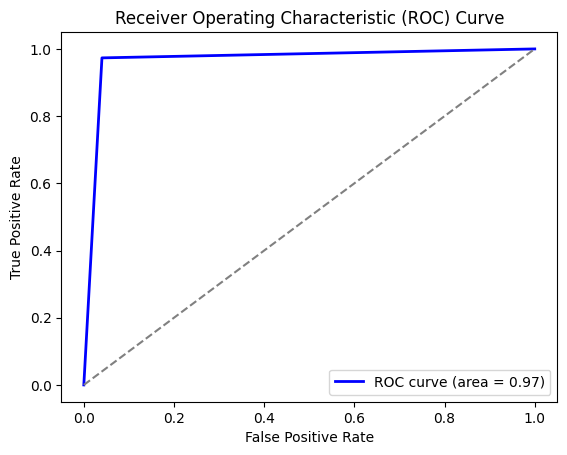

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Plot ROC curve with dummy values
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()

In [2]:
pip install networkx matplotlib


Note: you may need to restart the kernel to use updated packages.
